In [1]:
# Misc
import numpy as np
import pandas as pd
from tqdm import tqdm
import warnings

# Sklearn
from sklearn.preprocessing import MinMaxScaler
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Pytorch
import torch
import torch.nn as nn
from torch.autograd import Variable
import torch.nn.functional as F

# Keras (for a utility function)
import keras

# SVD
from numpy.linalg import svd

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')
np.set_printoptions(suppress=True)
tqdm.pandas()

2026-01-26 14:44:46.110965: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1769467486.132851 2573572 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1769467486.139199 2573572 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-01-26 14:44:46.160512: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# Clipping function to keep data within valid bounds
def clip(current, low_bound, up_bound):
    low_bound = torch.FloatTensor(low_bound)
    up_bound = torch.FloatTensor(up_bound)
    clipped = torch.max(torch.min(current, up_bound), low_bound)
    return clipped


def lowProFool(x, model, weights, bounds, maxiters, alpha, lambda_):
    """
    Generates an adversarial examples x' from an original sample x
    (Corrected Version)
    """

    # --- Initial Setup ---
    r = Variable(torch.FloatTensor(1e-4 * np.ones(x.numpy().shape)), requires_grad=True)
    v = torch.FloatTensor(np.array(weights))

    output = model.forward(x + r)
    orig_pred = output.max(0, keepdim=True)[1].cpu().numpy()
    target_pred = np.abs(1 - orig_pred)

    target = [0., 1.] if target_pred == 1 else [1., 0.]
    target = Variable(torch.tensor(target, requires_grad=False))

    lambda_ = torch.tensor([lambda_])
    bce = nn.BCELoss()
    l2 = lambda v, r: torch.sqrt(torch.sum(torch.mul(v * r, v * r))) # L2 norm

    # --- Optimization Loop ---
    loop_i = 0
    while loop_i < maxiters:

        model.zero_grad()

        # *** THE FIX IS HERE ***
        # The output must be recalculated inside the loop for the gradient to be correct.
        output = model.forward(x + r)

        # Computing loss with the UPDATED output
        loss_1 = bce(output, target)
        loss_2 = l2(v, r)
        loss = loss_1 + (lambda_ * loss_2)

        # Get the gradient
        loss.backward(retain_graph=True)
        grad_r = r.grad.data.cpu().numpy().copy()

        # Guide perturbation to the negative of the gradient
        ri = -grad_r
        ri *= alpha

        # Adds new perturbation to total perturbation
        # We need to detach r from the graph to update it
        r_new = r.clone().detach().cpu().numpy() + ri
        r = Variable(torch.FloatTensor(r_new), requires_grad=True)

        # Check if the class has flipped to stop early if needed
        with torch.no_grad():
            output_pred_check = model.forward(x + r).max(0, keepdim=True)[1].cpu().numpy()
            if output_pred_check != orig_pred:
                # If you want the attack to stop as soon as it succeeds, you can break here.
                # For a fixed-iteration attack as described in the paper, we let it run.
                pass

        loop_i += 1

    # --- Final Result ---
    # Clip the final adversarial example to stay within valid bounds
    best_pert_x = clip(x + r, bounds[0], bounds[1])
    output = model.forward(best_pert_x)
    output_pred = output.max(0, keepdim=True)[1].cpu().numpy()

    # The original function returned loop_change_class, we return the final loop_i
    return orig_pred, output_pred, best_pert_x.clone().detach().cpu().numpy(), loop_i



In [3]:
def get_df(dataset_name):
    dataset = fetch_openml(dataset_name)
    target_col = 'target'
    df = pd.DataFrame(data=np.c_[dataset['data'], dataset[target_col]], columns=dataset['feature_names'] + [target_col])
    df[target_col] = df[target_col].apply(lambda x: 0.0 if x == 'bad' else 1.0)

    feature_names = ['checking_status', 'duration', 'credit_amount', 'savings_status', 'employment',
                     'installment_commitment', 'residence_since', 'age', 'existing_credits',
                     'num_dependents', 'own_telephone', 'foreign_worker']
    df = df[feature_names + [target_col]]

    mappings = {
        'checking_status': {'<0': 0, '0<=X<200': 1, '>=200': 2, 'no checking': 3},
        'savings_status': {'no known savings': 0, '<100': 1, '100<=X<500': 2, '500<=X<1000': 3, '>=1000': 4},
        'employment': {'unemployed': 0, '<1': 1, '1<=X<4': 2, '4<=X<7': 3, '>=7': 4},
        'own_telephone': {'none': 0, 'yes': 1},
        'foreign_worker': {'no': 0, 'yes': 1}
    }
    for col, mapping in mappings.items():
        df[col] = df[col].map(mapping)
    df = df.astype(float)
    return df, target_col, feature_names

def normalize(df, feature_names):
    scaler = MinMaxScaler()
    X = df[feature_names].values
    low_bounds = X.min(axis=0)
    up_bounds = X.max(axis=0)

    df[feature_names] = scaler.fit_transform(X)

    scaled_bounds = [scaler.transform([low_bounds])[0], scaler.transform([up_bounds])[0]]
    return scaler, df, scaled_bounds

def get_weights(df, target_col):
    cor = df.corr()
    cor_target = abs(cor[target_col])
    weights = cor_target.drop(target_col).values
    weights = weights / np.linalg.norm(weights)
    return weights

In [4]:
class GermanNet(nn.Module):
    def __init__(self, D_in, H, D_out):
        super(GermanNet, self).__init__()
        self.linear1 = torch.nn.Linear(D_in, H)
        self.linear2 = torch.nn.Linear(H, H)
        self.linear3 = torch.nn.Linear(H, D_out)
        self.relu = torch.nn.ReLU()
        self.softmax = torch.nn.Softmax(dim=0)

    def forward(self, x):
        h1 = self.relu(self.linear1(x))
        h2 = self.relu(self.linear2(h1))
        a3 = self.linear3(h2)
        y = self.softmax(a3)
        return y

def train(model, X_train, y_train, epochs=200, batch_size=100, lr=1e-4):
    criterion = torch.nn.BCELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    n_classes = y_train.shape[1]

    model.train()
    print("Training model...")
    for epoch in range(epochs):
        for i in range(0, X_train.size(0), batch_size):
            inputs = Variable(X_train[i:i+batch_size], requires_grad=True)
            labels = y_train[i:i+batch_size]

            optimizer.zero_grad()
            output = model(inputs)
            loss = criterion(output, labels)
            loss.backward()
            optimizer.step()
    model.eval()
    print("Training complete.")
    return model

In [5]:
SEED = 42
DATASET = 'credit-g'

# Load and Prepare Data
df_orig, target, feature_names = get_df(DATASET)

# Balance dataset
len_0, len_1 = (df_orig[target] == 0).sum(), (df_orig[target] == 1).sum()
df_0 = df_orig[df_orig[target] == 0].sample(min(len_0, len_1), random_state=SEED)
df_1 = df_orig[df_orig[target] == 1].sample(min(len_0, len_1), random_state=SEED)
df = pd.concat((df_0, df_1)).sample(frac=1, random_state=SEED).reset_index(drop=True)

# Normalize data and get feature weights
scaler, df, bounds = normalize(df, feature_names)
weights = get_weights(df, target)

# Train/Test split
df_train, df_test = train_test_split(df, test_size=0.3, random_state=SEED)

print("Data loading and preparation complete.")
print(f"Training data shape: {df_train.shape}")
print(f"Test data shape: {df_test.shape}")
df_test.head()

Data loading and preparation complete.
Training data shape: (420, 13)
Test data shape: (180, 13)


,checking_status,duration,credit_amount,savings_status,employment,installment_commitment,residence_since,age,existing_credits,num_dependents,own_telephone,foreign_worker,target
110,0.0,0.294118,0.091175,0.25,0.50,0.333333,1.000000,0.035714,0.000000,1.0,0.0,1.0,0.0
419,0.0,0.058824,0.169192,0.25,0.75,0.000000,1.000000,0.357143,0.333333,0.0,0.0,0.0,1.0
565,1.0,0.382353,0.395168,0.00,0.00,1.000000,0.000000,0.607143,0.000000,0.0,1.0,1.0,0.0
77,0.0,0.073529,0.059936,0.25,0.25,0.666667,0.333333,0.142857,0.000000,0.0,1.0,1.0,0.0
181,0.0,0.294118,0.061042,0.25,0.75,1.000000,1.000000,0.071429,0.333333,0.0,0.0,1.0,0.0


In [6]:
X_train_tensor = torch.FloatTensor(df_train[feature_names].values)
y_train_tensor = torch.FloatTensor(keras.utils.to_categorical(df_train[target], num_classes=2))

model = GermanNet(D_in=len(feature_names), H=100, D_out=2)
model = train(model, X_train_tensor, y_train_tensor)

Training model...
Training complete.


In [7]:
# Use the entire test set for the attack
df_attack_samples = df_test

# This optional print statement helps confirm you are using all the data
print(f"Using the full test set of {len(df_attack_samples)} samples for analysis.")

print("\n--- Performing SVD on ORIGINAL Data ---")
original_matrix = df_attack_samples[feature_names].to_numpy()
print(f"\nProcessing original data matrix with shape: {original_matrix.shape}")

U_orig, s_orig, Vh_orig = svd(original_matrix, full_matrices=False)

print("SVD complete for original data.")
print(f"   Shape of U (left singular vectors):  {U_orig.shape}")
print(f"   Shape of s (singular values):        {s_orig.shape}")
print(f"   Shape of Vh (right singular vectors): {Vh_orig.shape}")

Using the full test set of 180 samples for analysis.

--- Performing SVD on ORIGINAL Data ---

Processing original data matrix with shape: (180, 12)
SVD complete for original data.
   Shape of U (left singular vectors):  (180, 12)
   Shape of s (singular values):        (12,)
   Shape of Vh (right singular vectors): (12, 12)


In [8]:
# ========================================================================== #
#    PARAMETERS TO CHANGE: Adjust these values to control attack intensity   #
# ========================================================================== #
config = {
    'MaxIters'     : 1000,    # Max iterations for the attack algorithms.
    'Alpha'        : 0.1,     # Step size / scaling factor for perturbations. Larger is more intense.
    'Lambda'       : 0.5,     # Trade-off for LowProFool. Smaller prioritizes fooling over stealth.
    'Model'        : model,
    'Weights'      : weights,
    'Bounds'       : bounds,
    'FeatureNames' : feature_names
}

# Generate adversarial examples for both methods
results_lpf = []


for _, row in tqdm(df_attack_samples.iterrows(), total=df_attack_samples.shape[0], desc="Generating Adversarials"):
    x_tensor = torch.FloatTensor(row[feature_names].values)

    # LowProFool - Call with explicit arguments from the config
    _, _, x_adv_lpf, _ = lowProFool(x=x_tensor,
                                    model=config['Model'],
                                    weights=config['Weights'],
                                    bounds=config['Bounds'],
                                    maxiters=config['MaxIters'],
                                    alpha=config['Alpha'],
                                    lambda_=config['Lambda'])
    results_lpf.append(x_adv_lpf)

df_adv_lpf = pd.DataFrame(results_lpf, columns=feature_names)

print("\nAdversarial example generation complete.")
print(f"Shape of LowProFool adversarial data: {df_adv_lpf.shape}")

Generating Adversarials: 100%|██████████| 180/180 [02:15<00:00,  1.33it/s]


Adversarial example generation complete.
Shape of LowProFool adversarial data: (180, 12)


In [9]:
print("\n--- Performing SVD on ADVERSARIAL Data ---")

# Convert pandas DataFrames to NumPy matrices
adv_matrix_lpf = df_adv_lpf.to_numpy()

# Perform SVD on the LowProFool adversarial matrix
print(f"\n1. Processing LowProFool matrix with shape: {adv_matrix_lpf.shape}")
U_lpf, s_lpf, Vh_lpf = svd(adv_matrix_lpf, full_matrices=False)
print("SVD complete for LowProFool.")
print(f"   Shape of U (left singular vectors):  {U_lpf.shape}")
print(f"   Shape of s (singular values):        {s_lpf.shape}")
print(f"   Shape of Vh (right singular vectors): {Vh_lpf.shape}")



--- Performing SVD on ADVERSARIAL Data ---

1. Processing LowProFool matrix with shape: (180, 12)
SVD complete for LowProFool.
   Shape of U (left singular vectors):  (180, 12)
   Shape of s (singular values):        (12,)
   Shape of Vh (right singular vectors): (12, 12)


# Systematic Perturbation Analysis

Now, we will perform a systematic analysis to understand how the data's structure changes as we increase the intensity of the adversarial attack.

Our process will be:
1.  Define a range of attack intensities (`Alpha` values).
2.  Loop through each intensity level. In each loop:
    - Generate a new set of adversarial examples.
    - Perform SVD and store the resulting singular values.
3.  Visualize the results in two ways:
    - **A line plot** to compare the singular value spectrums directly.
    - **A t-SNE plot** to visualize how the data points shift in a 2D space.

Starting systematic analysis...
--- Processing for Alpha = 0.01 ---


Alpha 0.01: 100%|██████████| 180/180 [02:13<00:00,  1.35it/s]


--- Processing for Alpha = 0.1 ---


Alpha 0.1: 100%|██████████| 180/180 [02:17<00:00,  1.31it/s]


--- Processing for Alpha = 1.0 ---


...

--- Processing for Alpha = 5.0 ---


Alpha 5.0: 100%|██████████| 180/180 [02:01<00:00,  1.48it/s]


--- Processing for Alpha = 10.0 ---


Alpha 10.0: 100%|██████████| 180/180 [02:14<00:00,  1.34it/s]



Analysis complete. All adversarial data generated and SVD performed.


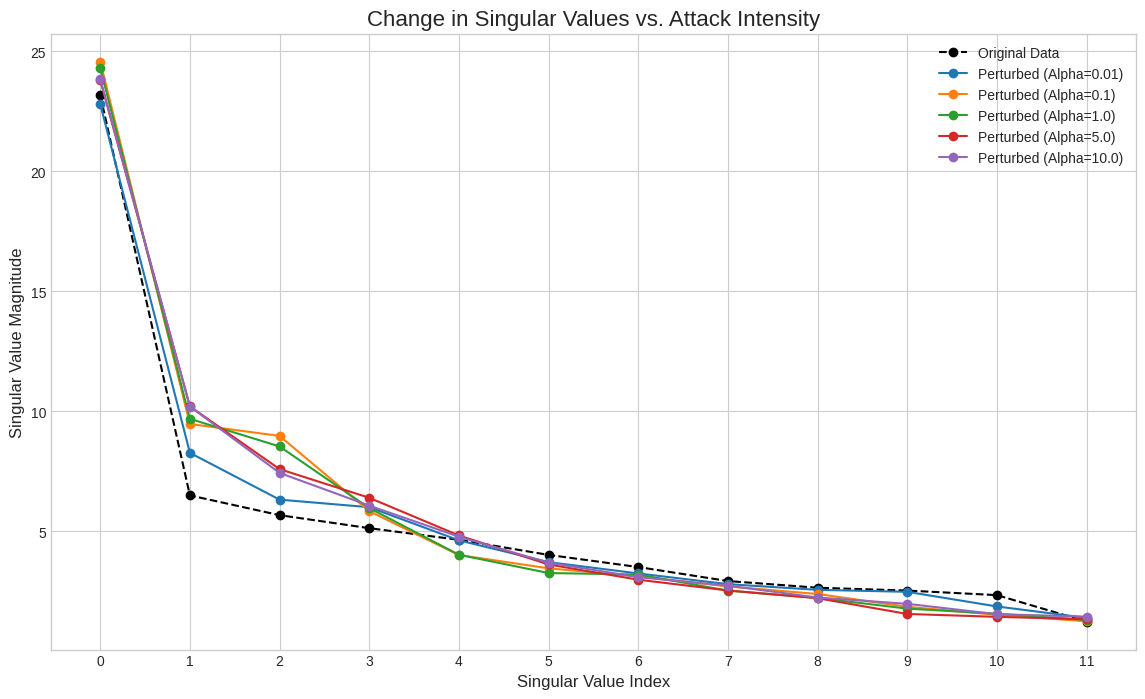

In [10]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

config = {
    'MaxIters'     : 1000,    # Max iterations for the attack algorithms.
    'Alpha'        : 0.1,     # Step size / scaling factor for perturbations. Larger is more intense.
    'Lambda'       : 0.5,     # Trade-off for LowProFool. Smaller prioritizes fooling over stealth.
    'Model'        : model,
    'Weights'      : weights,
    'Bounds'       : bounds,
    'FeatureNames' : feature_names
}

# --- 1. Define Experimental Parameters ---
# Define the different levels of attack intensity (Alpha) to test.
alpha_levels_to_test = [0.01, 0.1, 1.0, 5.0, 10.0]

# --- 2. Get Baseline SVD for Original Data ---
# We already have the original matrix and its SVD from Cell 8.
# original_matrix = df_attack_samples[feature_names].to_numpy()
# _, s_orig, _ = svd(original_matrix, full_matrices=False)

# --- 3. Loop, Generate Data, and Store SVD Results ---
singular_values_results = {}
adversarial_dataframes = {} # To store data for t-SNE

print("Starting systematic analysis...")
for alpha_val in alpha_levels_to_test:
    print(f"--- Processing for Alpha = {alpha_val} ---")

    # Generate adversarial examples for the current alpha
    current_results = []
    for _, row in tqdm(df_attack_samples.iterrows(), total=df_attack_samples.shape[0], desc=f"Alpha {alpha_val}"):
        x_tensor = torch.FloatTensor(row[feature_names].values)

        # Using LowProFool for this analysis
        _, _, x_adv, _ = lowProFool(x=x_tensor,
                                    model=config['Model'],
                                    weights=config['Weights'],
                                    bounds=config['Bounds'],
                                    maxiters=config['MaxIters'],
                                    alpha=alpha_val,  # Use the current alpha from the loop
                                    lambda_=config['Lambda'])
        current_results.append(x_adv)

    # Create a dataframe for the generated data
    df_adv_current = pd.DataFrame(current_results, columns=feature_names, index=df_attack_samples.index)
    adversarial_dataframes[alpha_val] = df_adv_current

    # Perform SVD and store the singular values
    adv_matrix_current = df_adv_current.to_numpy()
    _, s_current, _ = svd(adv_matrix_current, full_matrices=False)
    singular_values_results[alpha_val] = s_current

print("\nAnalysis complete. All adversarial data generated and SVD performed.")


# --- 4. Visualize the Singular Values ---
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(14, 8))

# Plot the original singular values as a baseline
plt.plot(s_orig, marker='o', linestyle='--', color='black', label='Original Data')

# Plot the singular values for each alpha level
for alpha_val, s_perturbed in singular_values_results.items():
    plt.plot(s_perturbed, marker='o', linestyle='-', label=f'Perturbed (Alpha={alpha_val})')

plt.title('Change in Singular Values vs. Attack Intensity', fontsize=16)
plt.xlabel('Singular Value Index', fontsize=12)
plt.ylabel('Singular Value Magnitude', fontsize=12)
plt.xticks(range(len(s_orig)))
plt.legend()
plt.grid(True)
plt.show()


Running t-SNE... (this may take a moment)
t-SNE complete.


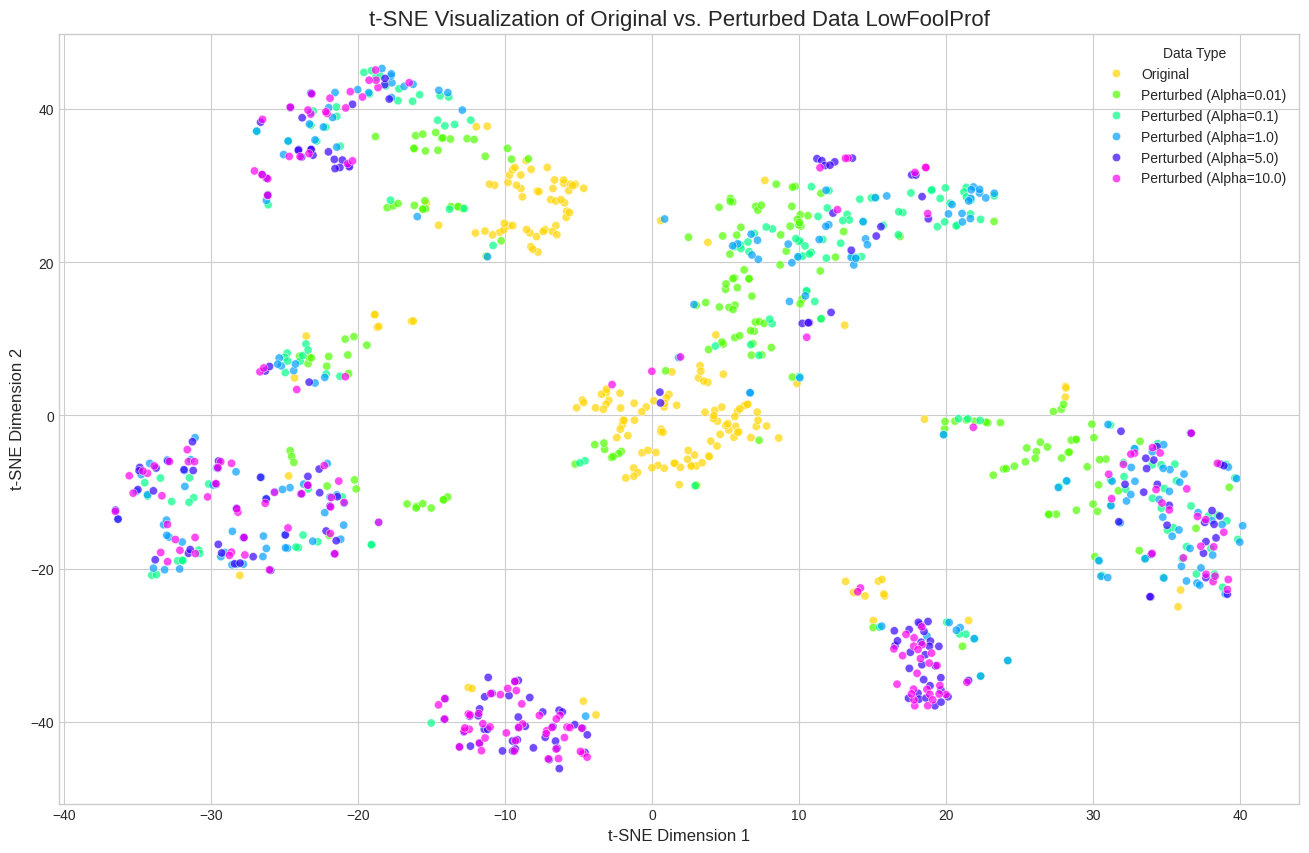

In [11]:
# --- 5. Visualize Data Manifold with t-SNE ---

# Prepare the data for t-SNE by combining all dataframes
all_dfs_for_tsne = []

# Add the original data first
df_original_for_tsne = df_attack_samples[feature_names].copy()
df_original_for_tsne['data_type'] = 'Original'
all_dfs_for_tsne.append(df_original_for_tsne)

# Add the adversarial dataframes
for alpha_val, df_adv in adversarial_dataframes.items():
    df_adv_copy = df_adv.copy()
    df_adv_copy['data_type'] = f'Perturbed (Alpha={alpha_val})'
    all_dfs_for_tsne.append(df_adv_copy)

# Concatenate into one big dataframe
combined_df = pd.concat(all_dfs_for_tsne, ignore_index=True)

# Separate features and labels
features = combined_df.drop('data_type', axis=1)
labels = combined_df['data_type']

print("\nRunning t-SNE... (this may take a moment)")
tsne = TSNE(n_components=2, verbose=0, perplexity=30, n_iter=1000, random_state=SEED)
tsne_results = tsne.fit_transform(features)
print("t-SNE complete.")

# Add t-SNE results back to the dataframe
combined_df['tsne-2d-one'] = tsne_results[:,0]
combined_df['tsne-2d-two'] = tsne_results[:,1]

# Plot the results
plt.figure(figsize=(16, 10))
sns.scatterplot(
    x="tsne-2d-one", y="tsne-2d-two",
    hue="data_type",
    palette=sns.color_palette("hsv", len(alpha_levels_to_test) + 1),
    data=combined_df,
    legend="full",
    alpha=0.7
)
plt.title('t-SNE Visualization of Original vs. Perturbed Data LowFoolProf', fontsize=16)
plt.xlabel('t-SNE Dimension 1', fontsize=12)
plt.ylabel('t-SNE Dimension 2', fontsize=12)
plt.legend(title='Data Type')
plt.grid(True)
plt.show()

Starting systematic analysis for Lambda (with Alpha fixed at 0.1)...
--- Processing for Lambda = 0.1 ---


Lambda 0.1: 100%|██████████| 180/180 [02:21<00:00,  1.27it/s]


--- Processing for Lambda = 0.5 ---


Lambda 0.5: 100%|██████████| 180/180 [02:23<00:00,  1.25it/s]


--- Processing for Lambda = 1.0 ---


...

--- Processing for Lambda = 10.0 ---


Lambda 10.0: 100%|██████████| 180/180 [02:11<00:00,  1.36it/s]


--- Processing for Lambda = 50.0 ---


Lambda 50.0: 100%|██████████| 180/180 [02:16<00:00,  1.32it/s]



Analysis complete. All adversarial data for Lambda test generated and SVD performed.


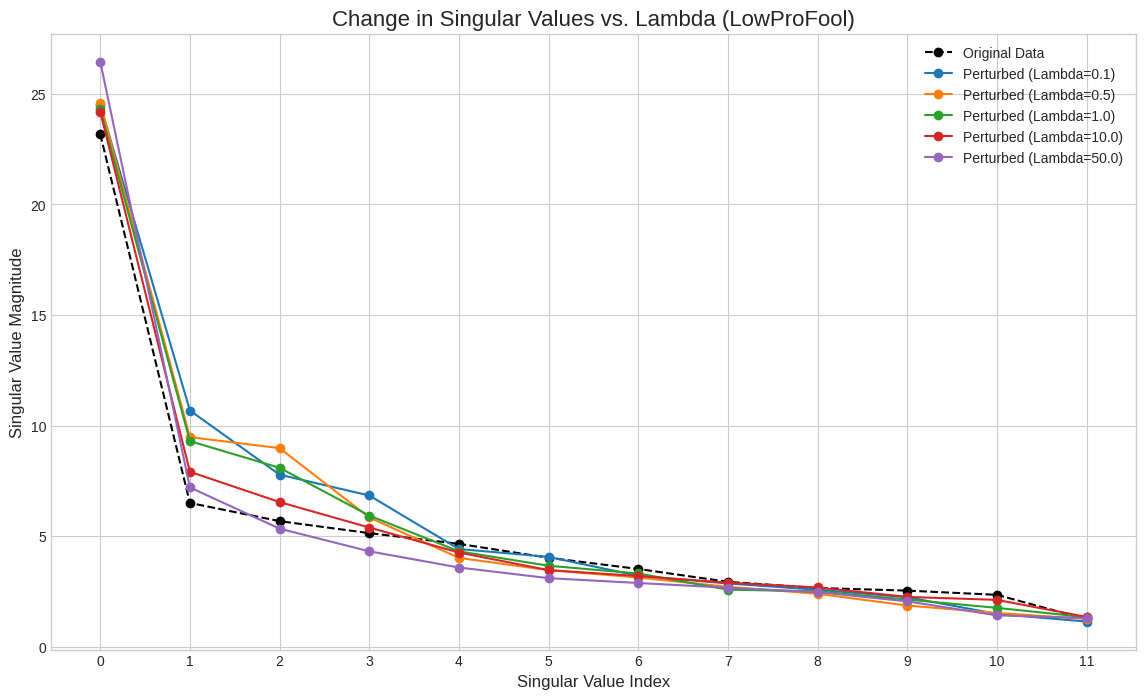

In [12]:
# ===================================================================
# Self-contained imports to make this cell runnable independently
# ===================================================================
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Define Experimental Parameters for Lambda ---
# Define the different levels of lambda to test.
lambda_values_to_test = [0.1, 0.5, 1.0, 10.0, 50.0]

# For this experiment, we keep Alpha constant to isolate the effect of Lambda.
alpha_for_lambda_test = 0.1

# --- 2. Loop, Generate Data, and Store SVD & Dataframe Results ---
singular_values_lambda_results = {}
adversarial_dataframes_lambda = {} # <-- ADDED: To store data for t-SNE

print(f"Starting systematic analysis for Lambda (with Alpha fixed at {alpha_for_lambda_test})...")
for lambda_val in lambda_values_to_test:
    print(f"--- Processing for Lambda = {lambda_val} ---")

    # Generate adversarial examples for the current lambda
    current_results = []
    for _, row in tqdm(df_attack_samples.iterrows(), total=df_attack_samples.shape[0], desc=f"Lambda {lambda_val}"):
        x_tensor = torch.FloatTensor(row[feature_names].values)

        # Using LowProFool for this analysis
        _, _, x_adv, _ = lowProFool(x=x_tensor,
                                    model=config['Model'],
                                    weights=config['Weights'],
                                    bounds=config['Bounds'],
                                    maxiters=config['MaxIters'],
                                    alpha=alpha_for_lambda_test, # Using the fixed alpha
                                    lambda_=lambda_val)          # Using the current lambda from the loop
        current_results.append(x_adv)

    # Create a dataframe for the generated data
    df_adv_current = pd.DataFrame(current_results, columns=feature_names, index=df_attack_samples.index)
    adversarial_dataframes_lambda[lambda_val] = df_adv_current # <-- ADDED: Save the dataframe

    # Perform SVD and store the singular values
    adv_matrix_current = df_adv_current.to_numpy()
    _, s_current, _ = svd(adv_matrix_current, full_matrices=False)
    singular_values_lambda_results[lambda_val] = s_current

print("\nAnalysis complete. All adversarial data for Lambda test generated and SVD performed.")


# --- 3. Visualize the Singular Values ---
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(14, 8))

# Plot the original singular values as a baseline
plt.plot(s_orig, marker='o', linestyle='--', color='black', label='Original Data')

# Plot the singular values for each lambda level
for lambda_val, s_perturbed in singular_values_lambda_results.items():
    plt.plot(s_perturbed, marker='o', linestyle='-', label=f'Perturbed (Lambda={lambda_val})')

plt.title('Change in Singular Values vs. Lambda (LowProFool)', fontsize=16)
plt.xlabel('Singular Value Index', fontsize=12)
plt.ylabel('Singular Value Magnitude', fontsize=12)
plt.xticks(range(len(s_orig)))
plt.legend()
plt.grid(True)
plt.show()


Running t-SNE for Lambda results... (this may take a moment)


t-SNE complete.


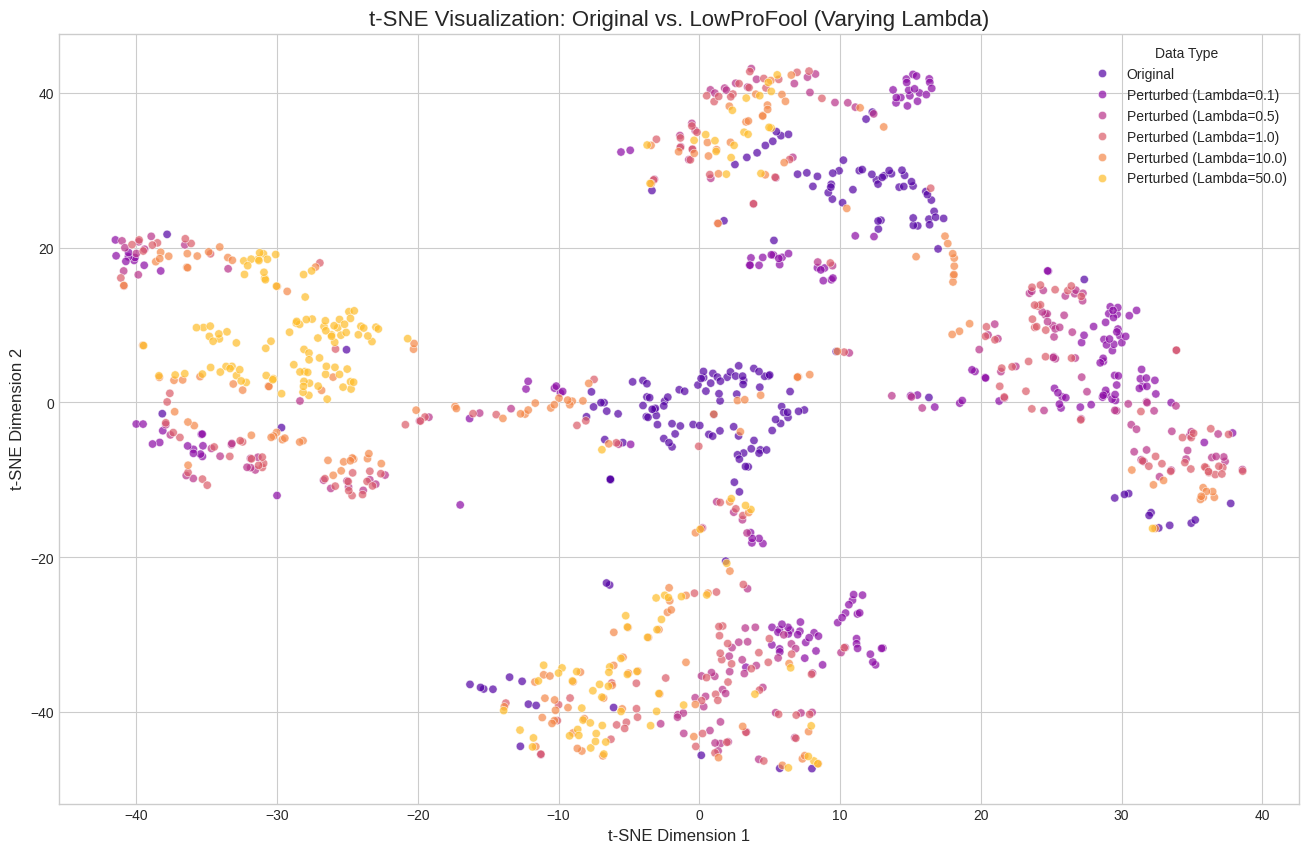

In [13]:
# ===================================================================
# Self-contained imports to make this cell runnable independently
# ===================================================================
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# --- Visualize Data Manifold with t-SNE for Lambda Analysis ---

# Prepare the data for t-SNE by combining all dataframes
all_dfs_for_tsne_lambda = []

# Add the original data first
df_original_for_tsne = df_attack_samples[feature_names].copy()
df_original_for_tsne['data_type'] = 'Original'
all_dfs_for_tsne_lambda.append(df_original_for_tsne)

# Add the adversarial dataframes from the Lambda analysis
# This assumes 'adversarial_dataframes_lambda' exists from the previous cell
for lambda_val, df_adv in adversarial_dataframes_lambda.items():
    df_adv_copy = df_adv.copy()
    df_adv_copy['data_type'] = f'Perturbed (Lambda={lambda_val})'
    all_dfs_for_tsne_lambda.append(df_adv_copy)

# Concatenate into one big dataframe
combined_df_lambda = pd.concat(all_dfs_for_tsne_lambda, ignore_index=True)

# Separate features and labels
features_lambda = combined_df_lambda.drop('data_type', axis=1)
labels_lambda = combined_df_lambda['data_type']

print("\nRunning t-SNE for Lambda results... (this may take a moment)")
tsne_lambda = TSNE(n_components=2, verbose=0, perplexity=30, n_iter=1000, random_state=SEED)
tsne_results_lambda = tsne_lambda.fit_transform(features_lambda)
print("t-SNE complete.")

# Add t-SNE results back to the dataframe
combined_df_lambda['tsne-2d-one'] = tsne_results_lambda[:,0]
combined_df_lambda['tsne-2d-two'] = tsne_results_lambda[:,1]

# Plot the results
plt.figure(figsize=(16, 10))
sns.scatterplot(
    x="tsne-2d-one", y="tsne-2d-two",
    hue="data_type",
    palette=sns.color_palette("plasma", len(lambda_values_to_test) + 1),
    data=combined_df_lambda,
    legend="full",
    alpha=0.7
)
plt.title('t-SNE Visualization: Original vs. LowProFool (Varying Lambda)', fontsize=16)
plt.xlabel('t-SNE Dimension 1', fontsize=12)
plt.ylabel('t-SNE Dimension 2', fontsize=12)
plt.legend(title='Data Type')
plt.grid(True)
plt.show()

Starting LowProFool analysis for Alpha (with Lambda fixed at 0.5)...
--- Processing for Alpha = 0.01 ---


Alpha 0.01: 100%|██████████| 180/180 [02:13<00:00,  1.35it/s]


Success Rate for Alpha=0.01: 100.00%
--- Processing for Alpha = 0.1 ---


Alpha 0.1: 100%|██████████| 180/180 [02:09<00:00,  1.39it/s]


Success Rate for Alpha=0.1: 95.56%
--- Processing for Alpha = 0.5 ---


...

Success Rate for Alpha=1.0: 88.33%
--- Processing for Alpha = 5.0 ---


Alpha 5.0: 100%|██████████| 180/180 [02:14<00:00,  1.34it/s]


Success Rate for Alpha=5.0: 91.67%
--- Processing for Alpha = 10.0 ---


Alpha 10.0: 100%|██████████| 180/180 [02:10<00:00,  1.38it/s]


Success Rate for Alpha=10.0: 90.00%


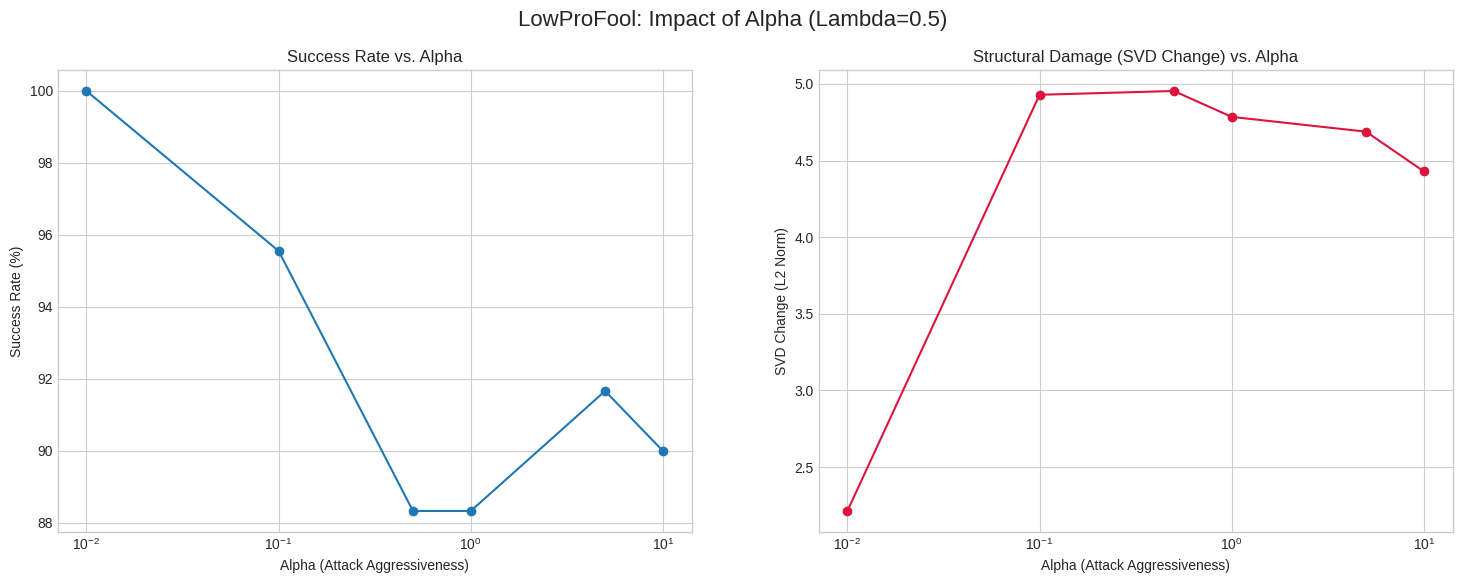

In [14]:
# ===================================================================
# Self-contained imports to make this cell runnable independently
# ===================================================================
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from numpy.linalg import svd
import numpy as np

# ===================================================================
# Main Experiment Setup
# ===================================================================

config = {
    'MaxIters'     : 1000,    # Max iterations for the attack algorithms.
    'Alpha'        : 0.1,     # Step size / scaling factor for perturbations. Larger is more intense.
    'Lambda'       : 0.5,     # Trade-off for LowProFool. Smaller prioritizes fooling over stealth.
    'Model'        : model,
    'Weights'      : weights,
    'Bounds'       : bounds,
    'FeatureNames' : feature_names
}

# --- 1. Define Experimental Parameters ---
alpha_values_to_test = [0.01, 0.1, 0.5, 1.0, 5.0, 10.0]
# Keep Lambda constant to isolate the effect of Alpha. A moderate value is good for this test.
lambda_for_alpha_test = 0.5

# This list will store a dictionary for each experimental run
lpf_alpha_results = []

print(f"Starting LowProFool analysis for Alpha (with Lambda fixed at {lambda_for_alpha_test})...")
for alpha_val in alpha_values_to_test:
    print(f"--- Processing for Alpha = {alpha_val} ---")

    successful_attacks_counter = 0
    adversarial_examples = []

    for _, row in tqdm(df_attack_samples.iterrows(), total=df_attack_samples.shape[0], desc=f"Alpha {alpha_val}"):
        x_tensor = torch.FloatTensor(row[feature_names].values)

        # Using the corrected LowProFool function
        orig_pred, adv_pred, x_adv, _ = lowProFool(
            x=x_tensor, model=config['Model'], weights=config['Weights'],
            bounds=config['Bounds'], maxiters=1000,
            alpha=alpha_val, lambda_=lambda_for_alpha_test
        )
        adversarial_examples.append(x_adv)

        # *** EFFICIENT SUCCESS CHECK (INSIDE THE LOOP) ***
        if orig_pred.item() != adv_pred.item():
            successful_attacks_counter += 1

    # --- Calculate Metrics for this alpha value ---
    # Calculate overall success rate
    success_rate = successful_attacks_counter / len(df_attack_samples)
    print(f"Success Rate for Alpha={alpha_val}: {success_rate:.2%}")

    # Perform SVD and calculate the structural change
    adv_matrix_current = np.array(adversarial_examples)
    _, s_perturbed, _ = svd(adv_matrix_current, full_matrices=False)
    svd_change = np.linalg.norm(s_orig - s_perturbed)

    # Store all results
    lpf_alpha_results.append({
        'alpha': alpha_val,
        'success_rate': success_rate,
        'svd_change': svd_change
    })

# --- 4. Prepare Data and Visualize ---
results_df_lpf_alpha = pd.DataFrame(lpf_alpha_results)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('LowProFool: Impact of Alpha (Lambda=0.5)', fontsize=16)

# Plot 1: Success Rate vs. Alpha
ax1.plot(results_df_lpf_alpha['alpha'], results_df_lpf_alpha['success_rate'] * 100, marker='o', linestyle='-')
ax1.set_title('Success Rate vs. Alpha')
ax1.set_xlabel('Alpha (Attack Aggressiveness)')
ax1.set_ylabel('Success Rate (%)')
ax1.set_xscale('log')
ax1.grid(True)

# Plot 2: SVD Change vs. Alpha
ax2.plot(results_df_lpf_alpha['alpha'], results_df_lpf_alpha['svd_change'], marker='o', linestyle='-', color='crimson')
ax2.set_title('Structural Damage (SVD Change) vs. Alpha')
ax2.set_xlabel('Alpha (Attack Aggressiveness)')
ax2.set_ylabel('SVD Change (L2 Norm)')
ax2.set_xscale('log')
ax2.grid(True)

plt.show()

Starting LowProFool analysis for Lambda (with Alpha fixed at 0.5)...
--- Processing for Lambda = 0.1 ---


Lambda 0.1: 100%|██████████| 180/180 [02:10<00:00,  1.38it/s]


Success Rate for Lambda=0.1: 100.00%
--- Processing for Lambda = 0.5 ---


Lambda 0.5: 100%|██████████| 180/180 [02:07<00:00,  1.41it/s]


Success Rate for Lambda=0.5: 88.33%
--- Processing for Lambda = 1.0 ---


...

Success Rate for Lambda=10.0: 89.44%
--- Processing for Lambda = 50.0 ---


Lambda 50.0: 100%|██████████| 180/180 [02:22<00:00,  1.26it/s]


Success Rate for Lambda=50.0: 95.00%
--- Processing for Lambda = 100.0 ---


Lambda 100.0: 100%|██████████| 180/180 [02:12<00:00,  1.36it/s]


Success Rate for Lambda=100.0: 92.78%


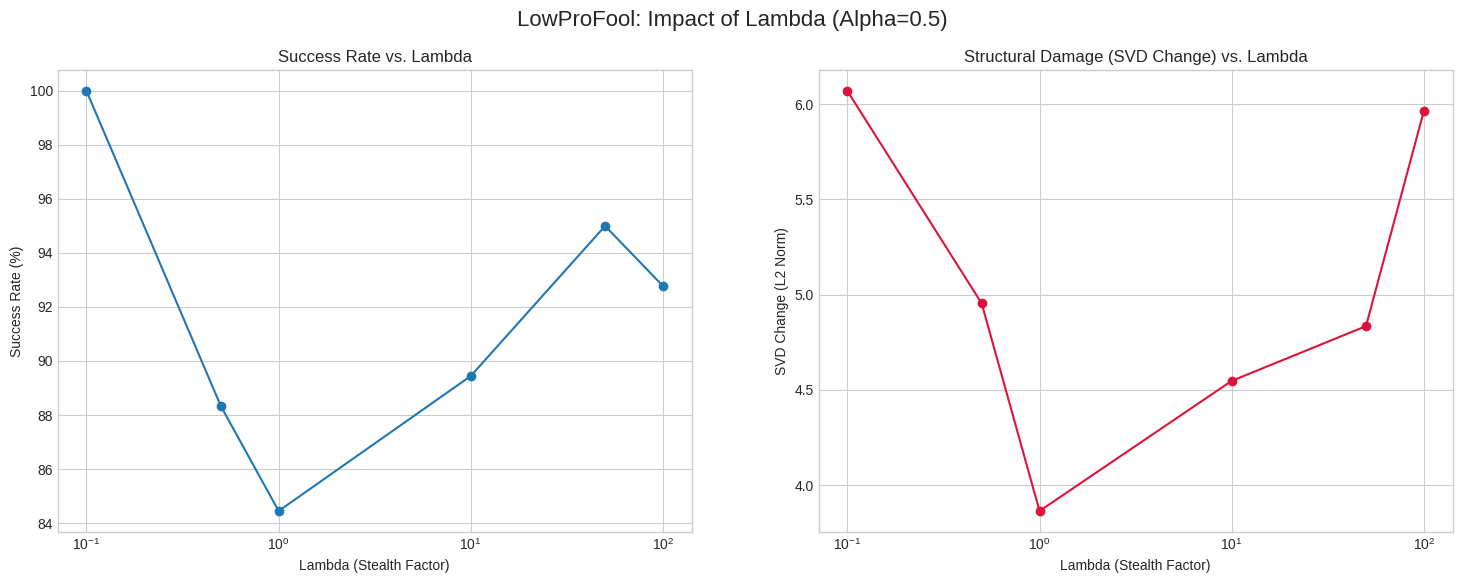

In [15]:
# ===================================================================
# Self-contained imports to make this cell runnable independently
# ===================================================================
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from numpy.linalg import svd
import numpy as np

# ===================================================================
# Main Experiment Setup
# ===================================================================

# --- 1. Define Experimental Parameters ---
lambda_values_to_test = [0.1, 0.5, 1.0, 10.0, 50.0, 100.0]
# Keep Alpha constant to isolate the effect of Lambda.
alpha_for_lambda_test = 0.5

# This list will store a dictionary for each experimental run
lpf_lambda_results = []

print(f"Starting LowProFool analysis for Lambda (with Alpha fixed at {alpha_for_lambda_test})...")
for lambda_val in lambda_values_to_test:
    print(f"--- Processing for Lambda = {lambda_val} ---")

    successful_attacks_counter = 0
    adversarial_examples = []

    for _, row in tqdm(df_attack_samples.iterrows(), total=df_attack_samples.shape[0], desc=f"Lambda {lambda_val}"):
        x_tensor = torch.FloatTensor(row[feature_names].values)

        # Using the corrected LowProFool function
        orig_pred, adv_pred, x_adv, _ = lowProFool(
            x=x_tensor, model=config['Model'], weights=config['Weights'],
            bounds=config['Bounds'], maxiters=1000,
            alpha=alpha_for_lambda_test, lambda_=lambda_val
        )
        adversarial_examples.append(x_adv)

        # *** EFFICIENT SUCCESS CHECK (INSIDE THE LOOP) ***
        if orig_pred.item() != adv_pred.item():
            successful_attacks_counter += 1

    # --- Calculate Metrics for this lambda value ---
    success_rate = successful_attacks_counter / len(df_attack_samples)
    print(f"Success Rate for Lambda={lambda_val}: {success_rate:.2%}")

    adv_matrix_current = np.array(adversarial_examples)
    _, s_perturbed, _ = svd(adv_matrix_current, full_matrices=False)
    svd_change = np.linalg.norm(s_orig - s_perturbed)

    lpf_lambda_results.append({
        'lambda': lambda_val,
        'success_rate': success_rate,
        'svd_change': svd_change
    })

# --- 4. Prepare Data and Visualize ---
results_df_lpf_lambda = pd.DataFrame(lpf_lambda_results)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('LowProFool: Impact of Lambda (Alpha=0.5)', fontsize=16)

# Plot 1: Success Rate vs. Lambda
ax1.plot(results_df_lpf_lambda['lambda'], results_df_lpf_lambda['success_rate'] * 100, marker='o', linestyle='-')
ax1.set_title('Success Rate vs. Lambda')
ax1.set_xlabel('Lambda (Stealth Factor)')
ax1.set_ylabel('Success Rate (%)')
ax1.set_xscale('log')
ax1.grid(True)

# Plot 2: SVD Change vs. Lambda
ax2.plot(results_df_lpf_lambda['lambda'], results_df_lpf_lambda['svd_change'], marker='o', linestyle='-', color='crimson')
ax2.set_title('Structural Damage (SVD Change) vs. Lambda')
ax2.set_xlabel('Lambda (Stealth Factor)')
ax2.set_ylabel('SVD Change (L2 Norm)')
ax2.set_xscale('log')
ax2.grid(True)

plt.show()

Starting systematic analysis for Alpha and Lambda...
--- Processing for Lambda = 0.1, Alpha = 0.01 ---


--- Processing for Lambda = 0.1, Alpha = 0.1 ---
--- Processing for Lambda = 0.1, Alpha = 1.0 ---
--- Processing for Lambda = 0.1, Alpha = 5.0 ---
--- Processing for Lambda = 0.1, Alpha = 10.0 ---
--- Processing for Lambda = 0.5, Alpha = 0.01 ---
--- Processing for Lambda = 0.5, Alpha = 0.1 ---
--- Processing for Lambda = 0.5, Alpha = 1.0 ---
--- Processing for Lambda = 0.5, Alpha = 5.0 ---
--- Processing for Lambda = 0.5, Alpha = 10.0 ---
--- Processing for Lambda = 1.0, Alpha = 0.01 ---
--- Processing for Lambda = 1.0, Alpha = 0.1 ---
--- Processing for Lambda = 1.0, Alpha = 1.0 ---
--- Processing for Lambda = 1.0, Alpha = 5.0 ---
--- Processing for Lambda = 1.0, Alpha = 10.0 ---
--- Processing for Lambda = 10.0, Alpha = 0.01 ---
--- Processing for Lambda = 10.0, Alpha = 0.1 ---
--- Processing for Lambda = 10.0, Alpha = 1.0 ---
--- Processing for Lambda = 10.0, Alpha = 5.0 ---
--- Processing for Lambda = 10.0, Alpha = 10.0 ---
--- Processing for Lambda = 50.0, Alpha = 0.01 ---
--- Pr

,lambda,alpha,success_rate,svd_change
0,0.1,0.01,0.994444,3.214813
1,0.1,0.10,0.994444,5.248686
2,0.1,1.00,0.933333,5.899035
3,0.1,5.00,0.933333,5.004151
4,0.1,10.00,0.900000,4.457107
5,0.5,0.01,0.994444,2.212917
6,0.5,0.10,0.933333,4.929059
7,0.5,1.00,0.866667,4.784812
8,0.5,5.00,0.905556,4.688422
9,0.5,10.00,0.883333,4.429237


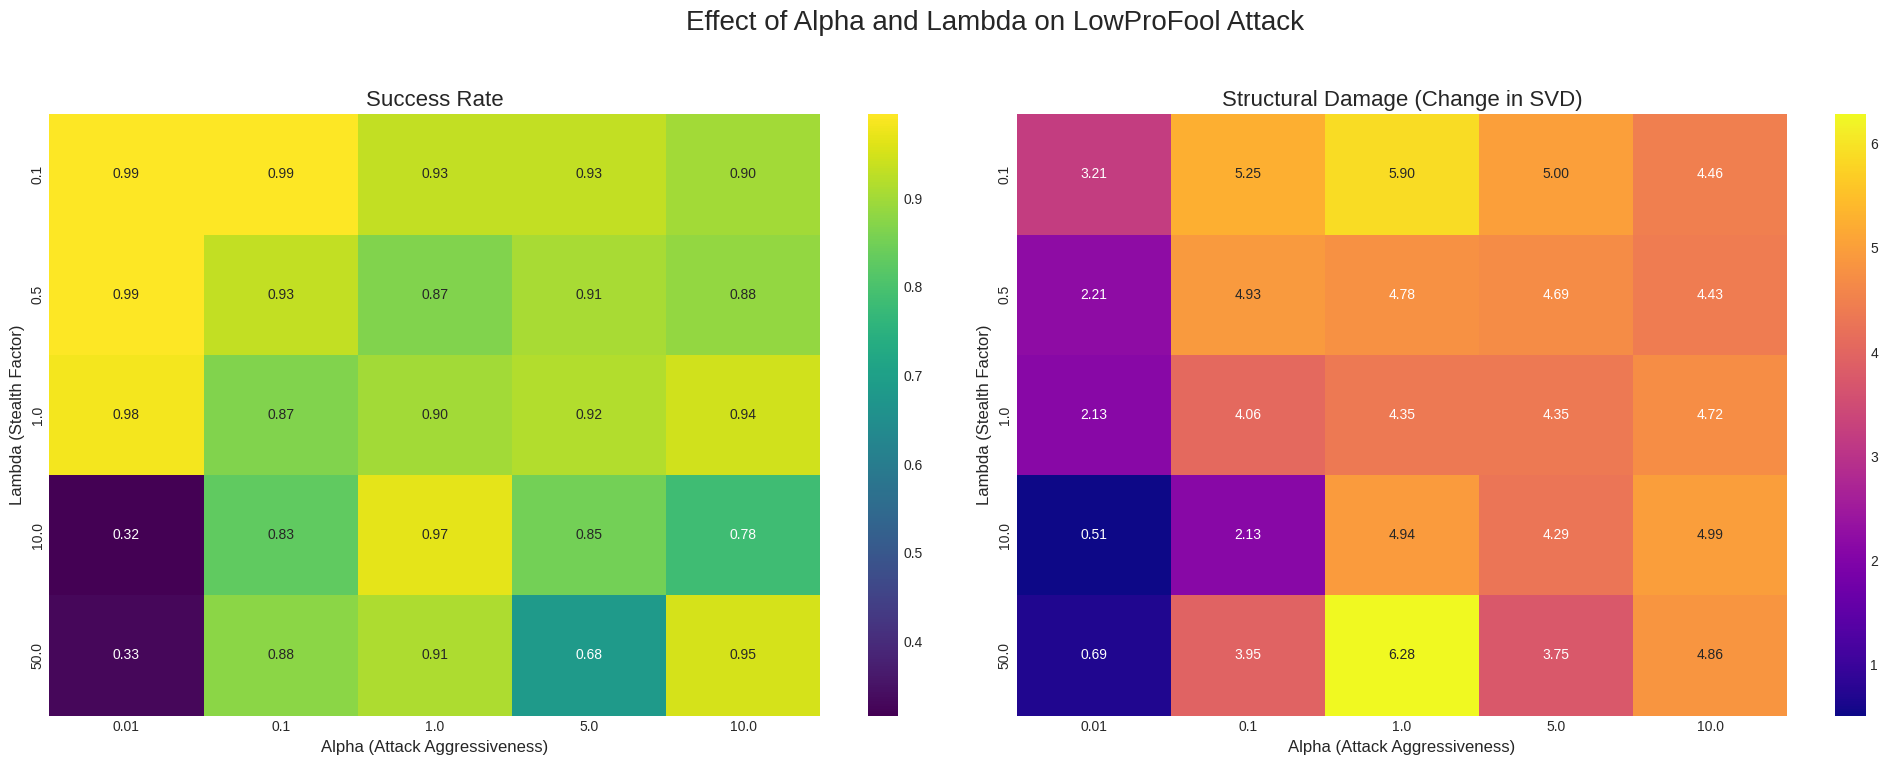

In [16]:
# ===================================================================
# Self-contained imports to make this cell runnable independently
# ===================================================================
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from numpy.linalg import svd
import numpy as np

# ===================================================================
# Helper function to calculate success rate
# ===================================================================
def calculate_success_rate(original_df, adversarial_df, model, feature_names):
    # Get predictions for the original, clean data
    x_orig_tensor = torch.FloatTensor(original_df[feature_names].values)
    with torch.no_grad():
        y_orig_pred = np.argmax(model(x_orig_tensor).numpy(), axis=1)

    # Get predictions for the new, adversarial data
    x_adv_tensor = torch.FloatTensor(adversarial_df[feature_names].values)
    with torch.no_grad():
        y_adv_pred = np.argmax(model(x_adv_tensor).numpy(), axis=1)

    # The attack is successful if the prediction is different
    successful_attacks = np.sum(y_orig_pred != y_adv_pred)

    return successful_attacks / len(original_df)

# ===================================================================
# Main Experiment Setup
# ===================================================================

# --- 1. Define Experimental Parameters ---
# Define the ranges of attack intensities (Alpha) and trade-offs (Lambda) to test.
lambda_values_to_test = [0.1, 0.5, 1.0, 10.0, 50.0]
alpha_values_to_test = [0.01, 0.1, 1.0, 5.0, 10.0]

# This list will store a dictionary for each experimental run
experimental_results = []

# --- 2. Nested Loop to Test All Combinations ---
print("Starting systematic analysis for Alpha and Lambda...")
for lambda_val in lambda_values_to_test:
    for alpha_val in alpha_values_to_test:
        print(f"--- Processing for Lambda = {lambda_val}, Alpha = {alpha_val} ---")

        current_adversarial_examples = []
        # Generate adversarial examples for the current parameter combination
        for _, row in df_attack_samples.iterrows():
            x_tensor = torch.FloatTensor(row[feature_names].values)

            # Using the corrected LowProFool function
            _, _, x_adv, _ = lowProFool(
                x=x_tensor, model=config['Model'], weights=config['Weights'],
                bounds=config['Bounds'], maxiters=1000, # Reduced iterations for speed
                alpha=alpha_val, lambda_=lambda_val
            )
            current_adversarial_examples.append(x_adv)

        # --- 3. Calculate Metrics for this combination ---
        df_adv_current = pd.DataFrame(current_adversarial_examples, columns=feature_names, index=df_attack_samples.index)

        # Calculate overall success rate
        success_rate = calculate_success_rate(df_attack_samples, df_adv_current, model, feature_names)

        # Perform SVD and calculate the structural change
        adv_matrix_current = df_adv_current.to_numpy()
        _, s_perturbed, _ = svd(adv_matrix_current, full_matrices=False)
        # We measure the "structural damage" as the distance between the original and perturbed singular value vectors
        svd_change = np.linalg.norm(s_orig - s_perturbed)

        # Store all results
        experimental_results.append({
            'lambda': lambda_val,
            'alpha': alpha_val,
            'success_rate': success_rate,
            'svd_change': svd_change
        })

print("\nFull analysis complete.")

# --- 4. Prepare Data for Visualization ---
results_df = pd.DataFrame(experimental_results)
print("\n--- Summary of Experimental Results ---")
display(results_df)

# Pivot the data to create matrices for the heatmaps
success_rate_pivot = results_df.pivot(index='lambda', columns='alpha', values='success_rate')
svd_change_pivot = results_df.pivot(index='lambda', columns='alpha', values='svd_change')

# --- 5. Visualize the Results ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle('Effect of Alpha and Lambda on LowProFool Attack', fontsize=20)

# Heatmap for Success Rate
sns.heatmap(success_rate_pivot, ax=ax1, annot=True, fmt=".2f", cmap="viridis")
ax1.set_title('Success Rate', fontsize=16)
ax1.set_xlabel('Alpha (Attack Aggressiveness)', fontsize=12)
ax1.set_ylabel('Lambda (Stealth Factor)', fontsize=12)

# Heatmap for SVD Change (Structural Damage)
sns.heatmap(svd_change_pivot, ax=ax2, annot=True, fmt=".2f", cmap="plasma")
ax2.set_title('Structural Damage (Change in SVD)', fontsize=16)
ax2.set_xlabel('Alpha (Attack Aggressiveness)', fontsize=12)
ax2.set_ylabel('Lambda (Stealth Factor)', fontsize=12)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()